# Stage 2-1. MNIST Raw Data Loading

이 노트북은 `load_mnist()`를 사용해 로컬 MNIST 파일을 로드하고,
반환되는 배열의 shape, dtype, 픽셀 분포를 확인한다.

**학습 목표**
1. `load_mnist(split)`의 반환값(images, labels)의 shape과 dtype을 확인한다.
2. `train` / `test` split 크기를 비교한다.
3. 샘플 이미지 16장을 grid로 시각화한다.
4. 픽셀값 분포를 histogram으로 확인한다.

## 0. 환경 설정

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import matplotlib.pyplot as plt

from src.data.mnist import load_mnist

## 1. 데이터 로드

`load_mnist(split)`은 로컬 `.gz` 파일을 파싱하여 원본 배열을 반환한다.

- `images`: `(N, 28, 28)` `uint8` — 픽셀값 범위 0~255
- `labels`: `(N,)` `uint8` — 클래스 0~9

In [2]:
train_images, train_labels = load_mnist("train")
test_images, test_labels = load_mnist("test")

print("[train]")
print(f"  images : shape={train_images.shape}, dtype={train_images.dtype}")
print(f"  labels : shape={train_labels.shape}, dtype={train_labels.dtype}")
print()
print("[test]")
print(f"  images : shape={test_images.shape}, dtype={test_images.dtype}")
print(f"  labels : shape={test_labels.shape}, dtype={test_labels.dtype}")

[train]
  images : shape=(60000, 28, 28), dtype=uint8
  labels : shape=(60000,), dtype=uint8

[test]
  images : shape=(10000, 28, 28), dtype=uint8
  labels : shape=(10000,), dtype=uint8


## 2. 픽셀값 범위 및 레이블 분포 확인

In [3]:
print("픽셀값 범위 (train):", train_images.min(), "~", train_images.max())
print("레이블 범위 (train):", train_labels.min(), "~", train_labels.max())
print()

# 레이블별 샘플 수
unique, counts = np.unique(train_labels, return_counts=True)
print("클래스별 샘플 수 (train):")
for cls, cnt in zip(unique, counts):
    print(f"  class {cls}: {cnt}")

픽셀값 범위 (train): 0 ~ 255
레이블 범위 (train): 0 ~ 9

클래스별 샘플 수 (train):
  class 0: 5923
  class 1: 6742
  class 2: 5958
  class 3: 6131
  class 4: 5842
  class 5: 5421
  class 6: 5918
  class 7: 6265
  class 8: 5851
  class 9: 5949


## 3. 샘플 이미지 16장 시각화

train set에서 클래스 0~9를 순서대로, 그리고 무작위 16장을 grid로 출력한다.

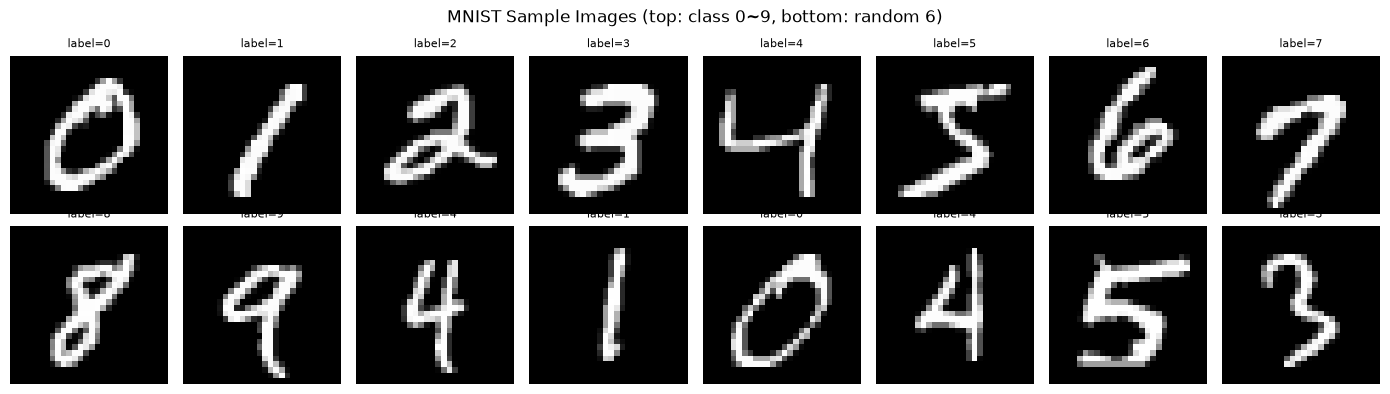

In [4]:
# 클래스별 대표 샘플 1장씩 (0~9) + 랜덤 6장
rng = np.random.default_rng(42)

class_samples = []
for cls in range(10):
    idx = np.where(train_labels == cls)[0][0]
    class_samples.append(idx)

random_indices = rng.choice(len(train_images), size=6, replace=False)
indices = class_samples + list(random_indices)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle("MNIST Sample Images (top: class 0~9, bottom: random 6)", fontsize=12)

for i, ax in enumerate(axes.flat):
    if i < len(indices):
        ax.imshow(train_images[indices[i]], cmap="gray")
        ax.set_title(f"label={train_labels[indices[i]]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. 픽셀값 분포 (Histogram)

MNIST 이미지는 배경(0)과 필기 획(높은 값)으로 구성된다.
픽셀 분포를 보면 대부분 0이고, 나머지는 넓게 퍼진 bimodal 분포를 보인다.

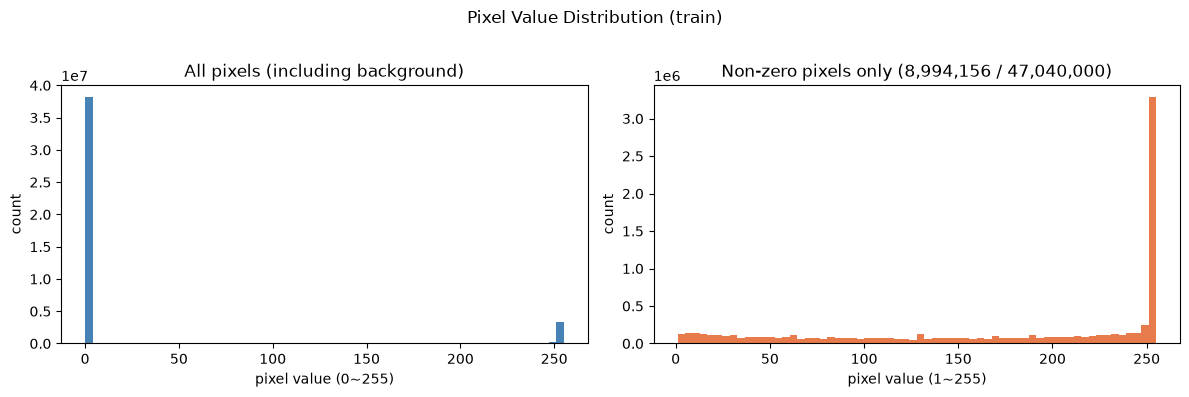

배경(0) 비율: 80.9%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Pixel Value Distribution (train)", fontsize=12)

# 전체 픽셀 분포
all_pixels = train_images.flatten()
axes[0].hist(all_pixels, bins=64, color="steelblue", edgecolor="none")
axes[0].set_title("All pixels (including background)")
axes[0].set_xlabel("pixel value (0~255)")
axes[0].set_ylabel("count")

# 배경(0) 제외한 분포
foreground_pixels = all_pixels[all_pixels > 0]
axes[1].hist(foreground_pixels, bins=64, color="#E87B4C", edgecolor="none")
axes[1].set_title(f"Non-zero pixels only ({len(foreground_pixels):,} / {len(all_pixels):,})")
axes[1].set_xlabel("pixel value (1~255)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

zero_ratio = np.sum(all_pixels == 0) / len(all_pixels) * 100
print(f"배경(0) 비율: {zero_ratio:.1f}%")

## 5. 단일 이미지 상세 확인

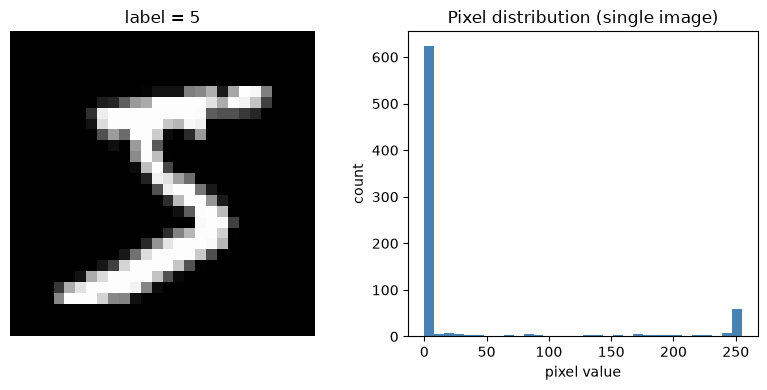

shape : (28, 28)
dtype : uint8
min/max: 0 / 255


In [6]:
# 첫 번째 train 샘플 상세 확인
sample_img = train_images[0]
sample_lbl = train_labels[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title(f"label = {sample_lbl}")
axes[0].axis("off")

axes[1].hist(sample_img.flatten(), bins=32, color="steelblue", edgecolor="none")
axes[1].set_title("Pixel distribution (single image)")
axes[1].set_xlabel("pixel value")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

print(f"shape : {sample_img.shape}")
print(f"dtype : {sample_img.dtype}")
print(f"min/max: {sample_img.min()} / {sample_img.max()}")

## 6. 정리

| 항목 | train | test |
|---|---|---|
| 샘플 수 | 60,000 | 10,000 |
| images shape | (60000, 28, 28) | (10000, 28, 28) |
| images dtype | uint8 | uint8 |
| labels shape | (60000,) | (10000,) |
| labels dtype | uint8 | uint8 |
| 픽셀 범위 | 0~255 | 0~255 |

**핵심 설계 원칙**
- `load_mnist()`는 원본 배열 그대로 반환한다. 정규화(`/255`)와 reshape은 `MnistDataset`이 담당한다.
- `split` 값은 `"train"` 또는 `"test"`만 허용하며, 다른 값은 `ValueError`를 발생시킨다.
- 이미지 원본은 `(N, 28, 28)` uint8이며, `MnistDataset`이 `(N, 784)` float32로 변환한다.